In [1]:
import json
import glob
import math
import os
import random
from collections import defaultdict
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.auto import tqdm
from ultralytics import YOLO

from datasets import load_dataset
from PIL import Image, ImageDraw, ImageOps
from transformers import AutoImageProcessor, TableTransformerForObjectDetection

try:
    from transformers import DetrImageProcessor as DetrFeatureExtractor
except Exception:
    from transformers import DetrFeatureExtractor
    
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import numpy as np
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



img_root_path = "/home/mohammed/Projects/STP/data/images"
annotations_path = "/home/mohammed/Projects/STP/data/annotations/Cells_Anotations_coco.json"
img_paths = glob.glob(os.path.join(img_root_path, "*.jpg"))


with open(annotations_path, 'r') as f:
    annotations = json.load(f) 


print(type(annotations))   
print(annotations.keys())  


def xyxy_to_xywh(boxes):
    x1, y1, x2, y2 = boxes
    return [x1, y1, x2 - x1, y2 - y1]

def xywh_to_xyxy(boxes):
    x, y, w, h = boxes
    return [x, y, x + w, y + h]

<class 'dict'>
dict_keys(['info', 'images', 'annotations', 'categories'])


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image


CATEGORY_COLORS = {
    1: ("table", "red"),
    2: ("table column", "cyan"),
    3: ("table row", "cyan"),
    4: ("table column header", "yellow"),
    5: ("table projected row header", "yellow"),
    6: ("table spanning cell", "green"),
}
def plot_table_boxes(image, predictions, figsize=(12, 16), format="xywh"):
    if isinstance(image, str):
        image = Image.open(image)

    fig, ax = plt.subplots(1, figsize=figsize)
    ax.imshow(image)

    for pred in predictions:
        cat_id = pred["category_id"]
        bbox = pred["bbox"]
        label, color = CATEGORY_COLORS.get(cat_id, (f"cat_{cat_id}", "white"))

        if format == "xywh":
            x1, y1, w, h = bbox
        else:
            x1, y1, x2, y2 = bbox
            w, h = x2 - x1, y2 - y1

        rect = patches.Rectangle(
            (x1, y1), w, h,
            linewidth=2.5,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, label, color=color, fontsize=7, fontweight="bold",
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1))

    handles = [
        patches.Patch(color=color, label=label)
        for _, (label, color) in CATEGORY_COLORS.items()
    ]
    ax.legend(handles=handles, loc="upper right", fontsize=8)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


In [3]:

td_processor = AutoImageProcessor.from_pretrained(
    "microsoft/table-transformer-detection",
    force_download=True
)
td_model = TableTransformerForObjectDetection.from_pretrained(
    "microsoft/table-transformer-detection",
    force_download=True
).to(DEVICE)

td_model.eval()


sr_model = TableTransformerForObjectDetection.from_pretrained(
    "microsoft/table-transformer-structure-recognition-v1.1-all"  
).to(DEVICE)


sr_processor = AutoImageProcessor.from_pretrained(
    "microsoft/table-transformer-structure-recognition-v1.1-all",size = {
    "longest_edge": 1000,
    "shortest_edge": 800
  }
)
checkpoint = torch.load("checkpoints/epoch_08_map0.8613.pt", map_location=DEVICE)

state_dict = checkpoint.get("model_state", checkpoint)  

sr_model.load_state_dict(state_dict, strict=True)
sr_model.eval()

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/273 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

/home/mohammed/miniconda3/envs/dl_env/lib/python3.10/site-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/home/mohammed/miniconda3/envs/dl_env/lib/python3.10/site-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/home/mohammed/miniconda3/envs/dl_env/lib/python3.10/site-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a n

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

TableTransformerForObjectDetection(
  (model): TableTransformerModel(
    (backbone): TableTransformerConvModel(
      (conv_encoder): TableTransformerConvEncoder(
        (model): ResNetBackbone(
          (embedder): ResNetEmbeddings(
            (embedder): ResNetConvLayer(
              (convolution): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
              (normalization): TableTransformerFrozenBatchNorm2d()
              (activation): ReLU()
            )
            (pooler): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          )
          (encoder): ResNetEncoder(
            (stages): ModuleList(
              (0): ResNetStage(
                (layers): Sequential(
                  (0): ResNetBasicLayer(
                    (shortcut): Identity()
                    (layer): Sequential(
                      (0): ResNetConvLayer(
                        (convolution): Conv2d(64, 64, kernel_size=(3, 3), stride=(

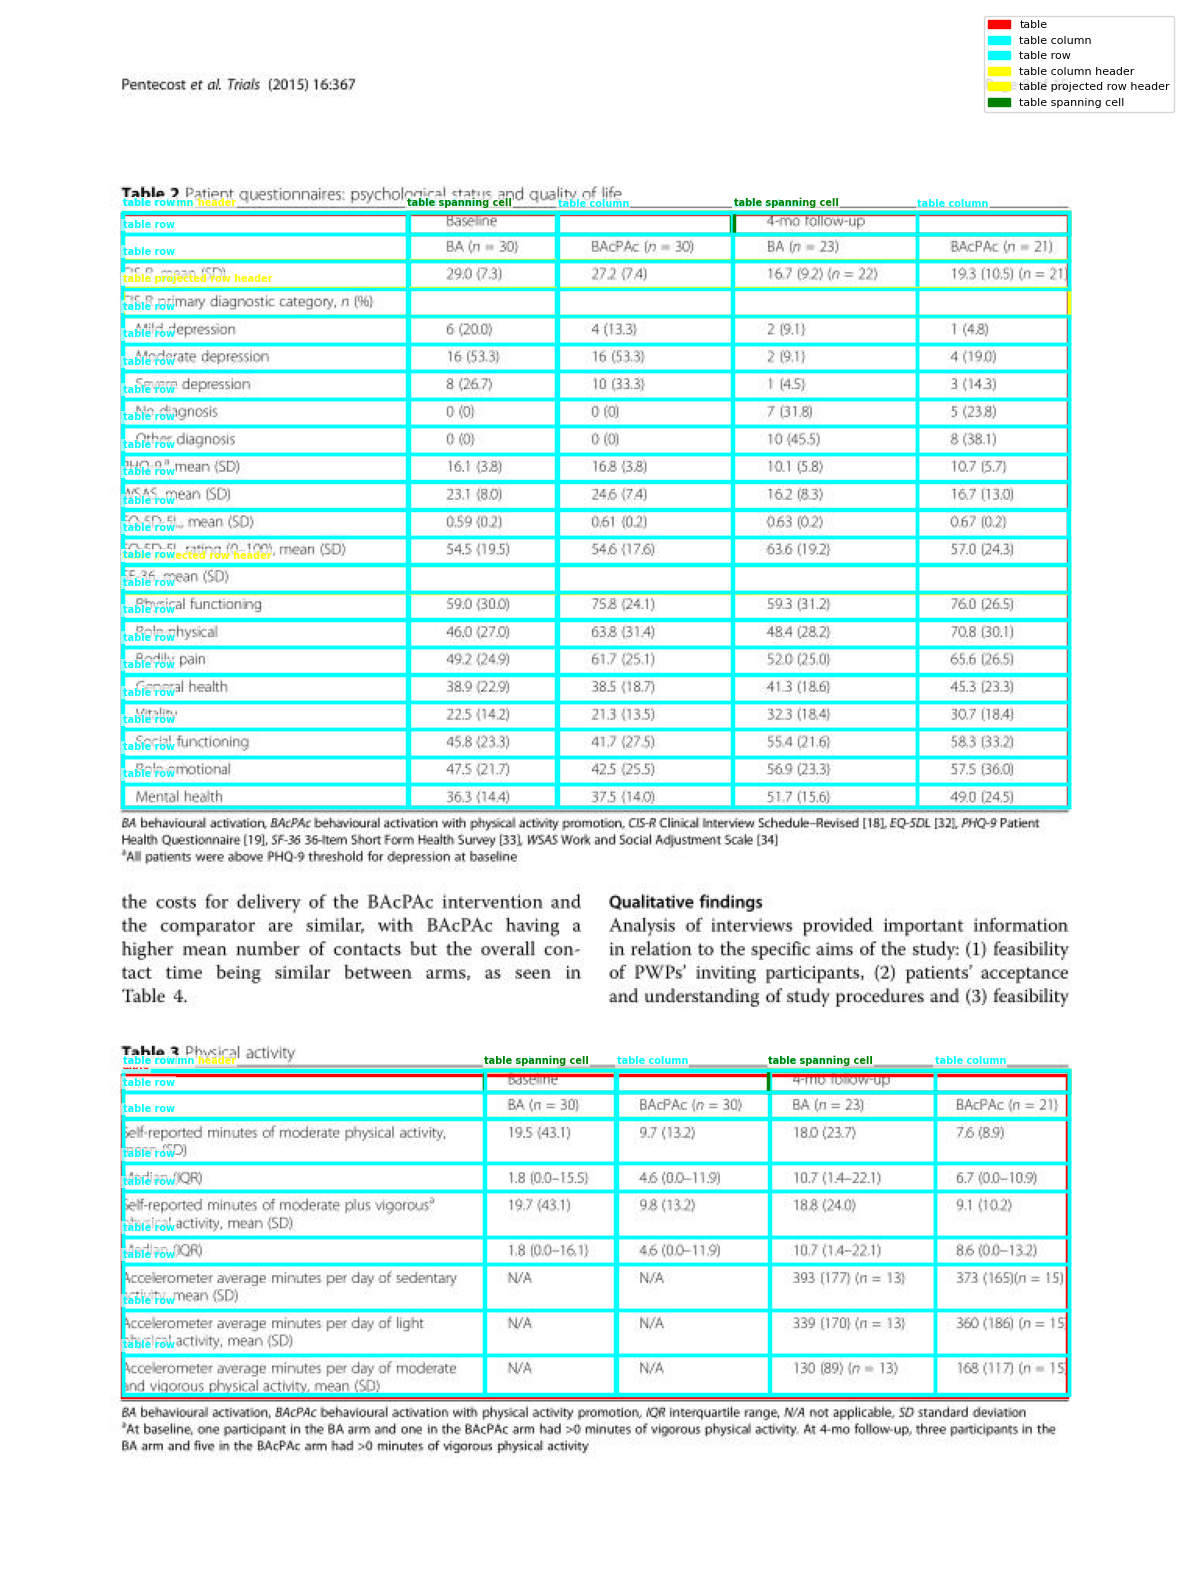

[{'category_id': 1, 'bbox': [71.12, 130.11, 606.87, 380.16999999999996]},
 {'category_id': 1,
  'bbox': [71.06, 682.5, 606.1600000000001, 206.17999999999995]},
 {'category_id': 3,
  'bbox': [71.68, 301.65, 606.3699999999999, 17.78000000000003]},
 {'category_id': 2, 'bbox': [255.03, 129.34, 94.77000000000001, 380.74]},
 {'category_id': 3, 'bbox': [71.78, 177.96, 606.4, 17.72]},
 {'category_id': 5,
  'bbox': [71.54, 355.37, 606.6600000000001, 17.69999999999999]},
 {'category_id': 2, 'bbox': [463.06, 129.55, 117.88000000000005, 380.68]},
 {'category_id': 4, 'bbox': [71.75, 129.21, 606.31, 30.799999999999983]},
 {'category_id': 6, 'bbox': [253.74, 129.23, 207.88, 14.02000000000001]},
 {'category_id': 3, 'bbox': [71.76, 248.79, 606.4, 17.669999999999987]},
 {'category_id': 3, 'bbox': [71.77, 372.54, 606.45, 17.72999999999996]},
 {'category_id': 3,
  'bbox': [71.82, 319.9, 606.1300000000001, 17.640000000000043]},
 {'category_id': 3,
  'bbox': [71.82, 143.29, 606.3499999999999, 16.99000000000

In [12]:

def predict(
    image_path:str
) -> Tuple[Image.Image, List[Dict[str, Any]]]:



    CATEGORY_MAP = {
    2: 1,  # table column
    3: 2,  # table row
    4: 3,  # table column header
    5: 4,  # table projected row header
    6: 5,  # table spanning cell
}
    ID2LABEL = {v: k for k, v in CATEGORY_MAP.items()}
    LABEL_NAMES = {
        0: 'table',
        1: 'table column',
        2: 'table row', 
        3:'table column header',
        4: 'table projected row header',
        5: 'table spanning cell'
        }

    
    image = Image.open(image_path).convert("RGB")
    orig_w, orig_h = image.size

    encoding = td_processor(images=image, return_tensors="pt" , do_resize=False)
    pixel_values = encoding["pixel_values"].to(DEVICE)  # (3, H, W)

    _ , _, actual_h, actual_w = pixel_values.shape

    scale_x = actual_w / orig_w
    scale_y = actual_h / orig_h

    with torch.no_grad():
        outputs = td_model(pixel_values=pixel_values)

    original_sizes =  torch.tensor([actual_h, actual_w]).unsqueeze(0)
    results = td_processor.post_process_object_detection(
        outputs,
        threshold=0.9,
        target_sizes=original_sizes.to(DEVICE)
    )


    orig_w, orig_h = image.size
    proc_h, proc_w = original_sizes.squeeze(0).tolist()
    scale_x = orig_w / proc_w
    scale_y = orig_h / proc_h


    tables_list = []
    image_labels = []
    crop_origins = []  
    for result, orig_size in zip(results, original_sizes):
        pred_boxes  = result["boxes"].detach().cpu()
        pred_scores = result["scores"].detach().cpu()
        for i, (box, score) in enumerate(zip(pred_boxes.tolist(), pred_scores.tolist())):
            px0, py0, px1, py1 = box
            px0_, py0_, px1_, py1_ = round(px0*scale_x , 2), round(py0*scale_y , 2), round(px1*scale_x , 2), round(py1*scale_y , 2)
            image_labels.append(
                {
                    "category_id":1,
                    "bbox":xyxy_to_xywh([px0_, py0_, px1_, py1_])
    }
                )
            pad = 5 # pixels
            ox0 = max(0,      px0_ - pad)
            oy0 = max(0,      py0_ - pad)
            ox1 = min(orig_w, px1_ + pad)
            oy1 = min(orig_h, py1_ + pad)
            crop = image.crop((ox0, oy0, ox1, oy1))
            tables_list.append(crop)
            crop_origins.append((ox0, oy0)) 




    for table , (ox0, oy0) in zip(tables_list, crop_origins):
        inputs = sr_processor(images=table, return_tensors="pt").to(DEVICE)
        target_sizes = torch.tensor([table.size[::-1]])

        with torch.no_grad():
            outputs = sr_model(**inputs)

        results = sr_processor.post_process_object_detection(
            outputs, threshold=0.9, target_sizes=target_sizes
        )[0]


        for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
            if label.item() not in LABEL_NAMES:
                continue
            


            x1, y1, x2, y2 = box.tolist()
            x1 += ox0
            y1 += oy0
            x2 += ox0
            y2 += oy0

            image_labels.append({
                "category_id": ID2LABEL[label.item()],
                "bbox": xyxy_to_xywh([round(x1, 2), round(y1, 2), round(x2, 2), round(y2, 2)])
            })
    return image , image_labels
        

    
image , image_labels = predict(img_paths[1401])
plot_table_boxes(image, image_labels)
image_labels

In [11]:
import json
import os
from typing import Tuple, List, Dict, Any

def predict(image_path: str) -> Dict[str, Any]:

    CATEGORY_MAP = {
        2: 1,  # table column
        3: 2,  # table row
        4: 3,  # table column header
        5: 4,  # table projected row header
        6: 5,  # table spanning cell
    }
    ID2LABEL = {v: k for k, v in CATEGORY_MAP.items()}
    LABEL_NAMES = {
        0: 'table',
        1: 'table column',
        2: 'table row',
        3: 'table column header',
        4: 'table projected row header',
        5: 'table spanning cell'
    }

    image = Image.open(image_path).convert("RGB")
    orig_w, orig_h = image.size

    encoding = td_processor(images=image, return_tensors="pt", do_resize=False)
    pixel_values = encoding["pixel_values"].to(DEVICE)

    _, _, actual_h, actual_w = pixel_values.shape

    with torch.no_grad():
        outputs = td_model(pixel_values=pixel_values)

    original_sizes = torch.tensor([actual_h, actual_w]).unsqueeze(0)
    td_results = td_processor.post_process_object_detection(
        outputs,
        threshold=0.9,
        target_sizes=original_sizes.to(DEVICE)
    )

    proc_h, proc_w = original_sizes.squeeze(0).tolist()
    scale_x = orig_w / proc_w
    scale_y = orig_h / proc_h

    detected_tables = []  # list of (ox0, oy0, ox1, oy1) in original coords
    table_crops = []

    for result in td_results:
        pred_boxes  = result["boxes"].detach().cpu().tolist()
        pred_scores = result["scores"].detach().cpu().tolist()

        for box, score in zip(pred_boxes, pred_scores):
            px0, py0, px1, py1 = box
            px0_ = round(px0 * scale_x, 2)
            py0_ = round(py0 * scale_y, 2)
            px1_ = round(px1 * scale_x, 2)
            py1_ = round(py1 * scale_y, 2)

            pad = 5
            ox0 = max(0,      px0_ - pad)
            oy0 = max(0,      py0_ - pad)
            ox1 = min(orig_w, px1_ + pad)
            oy1 = min(orig_h, py1_ + pad)

            detected_tables.append((ox0, oy0, ox1, oy1))
            table_crops.append(image.crop((ox0, oy0, ox1, oy1)))

    tables_output = []

    for table_id, (crop, (ox0, oy0, ox1, oy1)) in enumerate(
        zip(table_crops, detected_tables)
    ):
        inputs = sr_processor(images=crop, return_tensors="pt").to(DEVICE)
        target_sizes = torch.tensor([crop.size[::-1]])

        with torch.no_grad():
            sr_outputs = sr_model(**inputs)

        sr_results = sr_processor.post_process_object_detection(
            sr_outputs, threshold=0.9, target_sizes=target_sizes
        )[0]

        rows = []     # list of [x1, y1, x2, y2] in original image coords
        columns = []  # list of [x1, y1, x2, y2] in original image coords

        for score, label, box in zip(
            sr_results["scores"], sr_results["labels"], sr_results["boxes"]
        ):
            lbl = label.item()
            if lbl not in LABEL_NAMES:
                continue

            bx1, by1, bx2, by2 = box.tolist()
            bx1, bx2 = round(bx1 + ox0, 2), round(bx2 + ox0, 2)
            by1, by2 = round(by1 + oy0, 2), round(by2 + oy0, 2)

            if LABEL_NAMES[lbl] == 'table row':
                rows.append([bx1, by1, bx2, by2])
            elif LABEL_NAMES[lbl] == 'table column':
                columns.append([bx1, by1, bx2, by2])

        # Sort rows top→bottom, columns left→right
        rows    = sorted(rows,    key=lambda b: b[1])
        columns = sorted(columns, key=lambda b: b[0])

        cells = []
        for row_idx, row_box in enumerate(rows):
            for col_idx, col_box in enumerate(columns):
                # Intersection bbox
                cx1 = round(max(row_box[0], col_box[0]), 2)
                cy1 = round(max(row_box[1], col_box[1]), 2)
                cx2 = round(min(row_box[2], col_box[2]), 2)
                cy2 = round(min(row_box[3], col_box[3]), 2)

                if cx1 < cx2 and cy1 < cy2:
                    cells.append({
                        "bbox": [cx1, cy1, cx2, cy2],
                        "row":  row_idx,
                        "col":  col_idx
                    })

        tables_output.append({
            "table_id": table_id,
            "bbox": [round(ox0, 2), round(oy0, 2), round(ox1, 2), round(oy1, 2)],
            "cells": cells
        })

    output = {
        "filename": os.path.basename(image_path),
        "tables":   tables_output
    }

    return image, output



image, result = predict(img_paths[500])
print(json.dumps(result, indent=4))

{
    "filename": "PMC5956533_6.jpg",
    "tables": [
        {
            "table_id": 0,
            "bbox": [
                66.41,
                137.44,
                371.47,
                299.01
            ],
            "cells": [
                {
                    "bbox": [
                        71.76,
                        142.43,
                        199.9,
                        156.25
                    ],
                    "row": 0,
                    "col": 0
                },
                {
                    "bbox": [
                        200.29,
                        142.43,
                        319.5,
                        156.25
                    ],
                    "row": 0,
                    "col": 1
                },
                {
                    "bbox": [
                        319.69,
                        142.51,
                        367.74,
                        156.25
                    ],
        

In [ ]:
import json

final_results = []
for img_path in tqdm(img_paths):
    _, result = predict(img_path)
    final_results.append(result)

with open("results.json", "w") as f:
    json.dump(final_results, f, indent=4)

print(f"Saved {len(final_results)} results to results.json")